# Sentiment Analysis Project








## 1. Setup

In [4]:
import sys
print("Python version:", sys.version)
assert sys.version_info[:2] in [(3, 10), (3, 11), (3, 12)], (
    "This notebook expects Python 3.10-3.12 (3.11 recommended) for reliable "
    "wheel availability. If you see this assertion fail, activate the .venv "
    "created by setup.ps1/setup.sh and reselect the kernel in VS Code."
)


Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [ ]:
import os, sys, re, json, time, pickle, random, warnings
warnings.filterwarnings("ignore")


os.environ["USE_FLAX"] = "0"
for _mod_name in list(sys.modules):
    if _mod_name == "jax" or _mod_name.startswith("jax.") \
       or _mod_name == "transformers" or _mod_name.startswith("transformers."):
        del sys.modules[_mod_name]

import numpy as np
if not hasattr(np, "long"):
    np.long = int
if not hasattr(np, "ulong"):
    np.ulong = int

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import torch
torch.manual_seed(SEED)

# Local project layout (this notebook lives in <project_root>/notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, "raw"), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, "processed"), exist_ok=True)

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

print("Setup complete. Project root:", PROJECT_ROOT)



Setup complete. Project root: c:\Users\Admin\Desktop


## 2. Load Dataset & Compute Statistics

Loads IMDB via HuggingFace `datasets`, subsamples to a balanced set for
manageable training time, and reports the dataset statistics required by
the EDA phase: sample count, class distribution, text lengths, vocab size,
duplicates, missing values, and outlier reviews.


In [6]:
try:
    from datasets import load_dataset
except (ModuleNotFoundError, ImportError):
    %pip install -q "datasets==2.19.0"
    from datasets import load_dataset

N_SAMPLES = 6000          # total balanced reviews used; raise for more accuracy/compute
MAX_LEN = 200              # sequence length cap for RNN/LSTM/GRU
VOCAB_SIZE = 10000

# Note: the IMDB dataset repo on the Hub was renamed with a namespace prefix,
# so the older bare "imdb" no longer resolves with recent `datasets` versions.
raw = load_dataset("stanfordnlp/imdb")
full_df = pd.concat([
    pd.DataFrame(raw["train"]),
    pd.DataFrame(raw["test"]),
], ignore_index=True)

print("Full dataset size:", len(full_df))
print(full_df["label"].value_counts())


Full dataset size: 50000
label
0    25000
1    25000
Name: count, dtype: int64


In [7]:
# Balanced subsample for tractable training time
pos_df = full_df[full_df.label == 1].sample(N_SAMPLES // 2, random_state=SEED)
neg_df = full_df[full_df.label == 0].sample(N_SAMPLES // 2, random_state=SEED)
df = pd.concat([pos_df, neg_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)
df = df.rename(columns={"text": "review", "label": "sentiment"})

print("Working dataset size:", len(df))
df.head()


Working dataset size: 6000


,review,sentiment
0,"""Shower"" is an story about loyalty, about the ...",1
1,"this movie is similar to Darkness Falls,and Th...",0
2,"Seriously, can you imagine such a spread of ta...",1
3,"There is this private campground in Plymouth, ...",1
4,'Bland' is probably the word I'd use to try an...,0


In [8]:
# --- Dataset statistics ---
stats = {}
stats["n_samples"] = len(df)
stats["class_distribution"] = df["sentiment"].value_counts().to_dict()
stats["missing_values"] = int(df["review"].isna().sum())
stats["duplicate_reviews"] = int(df["review"].duplicated().sum())

df["review"] = df["review"].astype(str)
df["word_count"] = df["review"].str.split().apply(len)
df["char_count"] = df["review"].str.len()

stats["avg_review_length_words"] = float(df["word_count"].mean())
stats["median_review_length_words"] = float(df["word_count"].median())
stats["max_review_length_words"] = int(df["word_count"].max())
stats["min_review_length_words"] = int(df["word_count"].min())

vocab = set()
for review in df["review"].str.lower().str.split():
    vocab.update(review)
stats["vocab_size"] = len(vocab)

# Outliers: reviews far outside the typical length range (using IQR)
q1, q3 = df["word_count"].quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (df["word_count"] < q1 - 1.5 * iqr) | (df["word_count"] > q3 + 1.5 * iqr)
stats["n_outlier_reviews"] = int(outlier_mask.sum())

print(json.dumps(stats, indent=2))


{
  "n_samples": 6000,
  "class_distribution": {
    "1": 3000,
    "0": 3000
  },
  "missing_values": 0,
  "duplicate_reviews": 6,
  "avg_review_length_words": 230.95366666666666,
  "median_review_length_words": 173.0,
  "max_review_length_words": 1737,
  "min_review_length_words": 8,
  "vocab_size": 103140,
  "n_outlier_reviews": 445
}


In [9]:
# Drop duplicates and clip extreme outliers (keep within a sane word-count band)
df = df.drop_duplicates(subset="review").reset_index(drop=True)
df = df[(df["word_count"] >= 3) & (df["word_count"] <= 400)].reset_index(drop=True)
print("Dataset size after de-dup & outlier trim:", len(df))

df.to_csv(f"{DATA_DIR}/raw/imdb_raw.csv", index=False) if os.path.exists(f"{DATA_DIR}/raw") else None
os.makedirs(f"{DATA_DIR}/raw", exist_ok=True)
df.to_csv(f"{DATA_DIR}/raw/imdb_raw.csv", index=False)


Dataset size after de-dup & outlier trim: 5220


## 3. Exploratory Data Analysis (EDA)

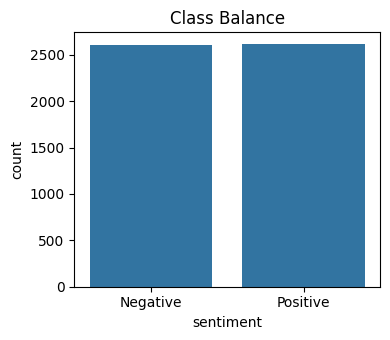

In [10]:
# Class balance
plt.figure(figsize=(4, 3.5))
sns.countplot(x="sentiment", data=df)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.title("Class Balance")
plt.tight_layout()
plt.show()


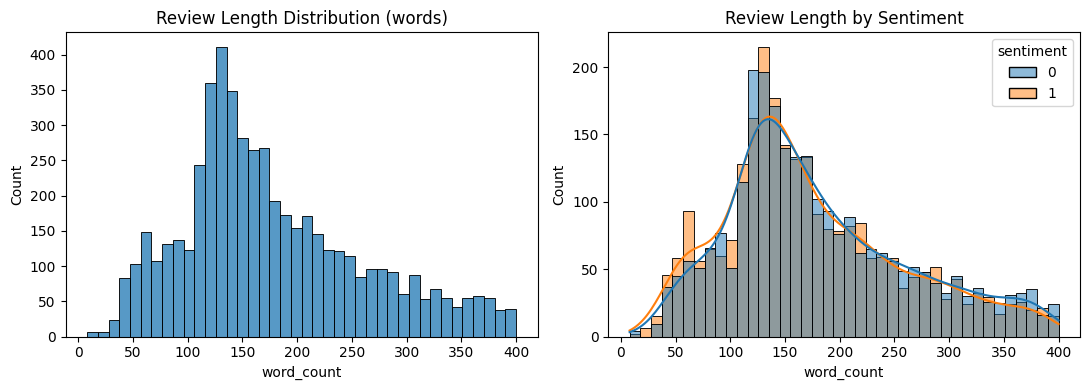

Review length vs sentiment correlation: -0.0421


In [11]:
# Review length distribution (overall and by class)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["word_count"], bins=40, ax=axes[0])
axes[0].set_title("Review Length Distribution (words)")

sns.histplot(data=df, x="word_count", hue="sentiment", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Review Length by Sentiment")
plt.tight_layout()
plt.show()

print("Review length vs sentiment correlation:",
      round(df["word_count"].corr(df["sentiment"]), 4))


In [12]:
# Most common words (excluding stopwords)
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words("english"))

def tokenize_simple(text):
    return re.findall(r"[a-z']+", text.lower())

all_tokens = [tok for review in df["review"] for tok in tokenize_simple(review) if tok not in stop_words]
word_freq = Counter(all_tokens)

print("Top 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

print("\nLeast common words (appearing exactly once):", sum(1 for c in word_freq.values() if c == 1))


Top 20 most common words:
  br: 16224
  movie: 8416
  film: 6477
  one: 4439
  like: 3453
  good: 2775
  time: 2171
  even: 2074
  would: 2006
  see: 1974
  really: 1965
  story: 1886
  well: 1802
  bad: 1746
  great: 1577
  much: 1572
  get: 1520
  movies: 1495
  first: 1483
  made: 1469

Least common words (appearing exactly once): 16375


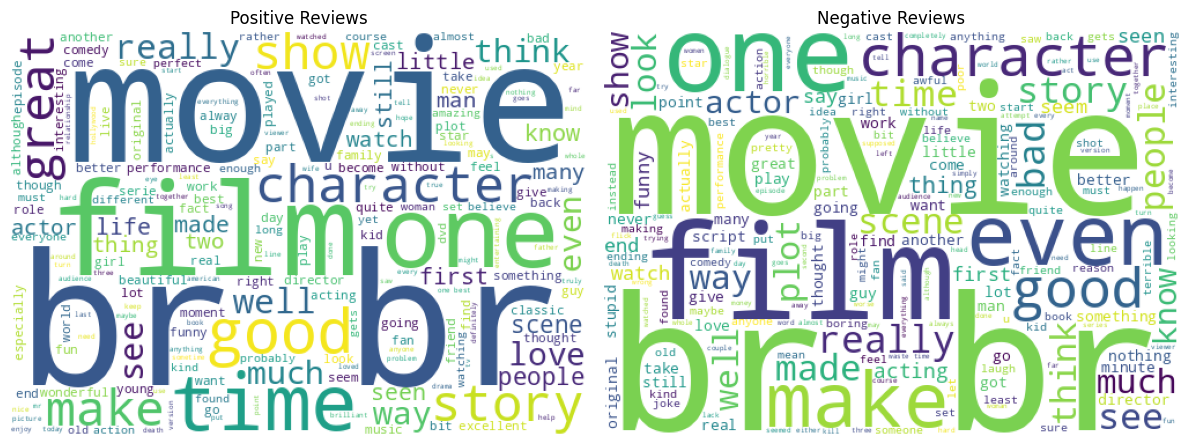

In [13]:
# Word clouds: positive vs negative
try:
    from wordcloud import WordCloud
except (ModuleNotFoundError, ImportError):
    %pip install -q "wordcloud==1.9.3"
    from wordcloud import WordCloud

pos_text = " ".join(w for review in df[df.sentiment == 1]["review"]
                     for w in tokenize_simple(review) if w not in stop_words)
neg_text = " ".join(w for review in df[df.sentiment == 0]["review"]
                     for w in tokenize_simple(review) if w not in stop_words)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(WordCloud(width=500, height=350, background_color="white").generate(pos_text))
axes[0].set_title("Positive Reviews")
axes[0].axis("off")

axes[1].imshow(WordCloud(width=500, height=350, background_color="white").generate(neg_text))
axes[1].set_title("Negative Reviews")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [14]:
# N-gram analysis (bigrams & trigrams)
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, n, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english", max_features=5000).fit(corpus)
    bag = vec.transform(corpus)
    sums = bag.sum(axis=0)
    freq = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(freq, key=lambda x: x[1], reverse=True)[:top_k]

print("Top bigrams:")
for w, c in top_ngrams(df["review"], 2):
    print(f"  {w}: {c}")

print("\nTop trigrams:")
for w, c in top_ngrams(df["review"], 3):
    print(f"  {w}: {c}")


Top bigrams:
  br br: 8127
  ve seen: 371
  br movie: 257
  br film: 233
  movie br: 220
  special effects: 217
  don know: 209
  low budget: 197
  waste time: 180
  film br: 163
  good movie: 162
  looks like: 157
  watch movie: 139
  br 10: 137
  movie just: 134

Top trigrams:
  br br movie: 257
  br br film: 233
  movie br br: 220
  film br br: 163
  br br 10: 137
  br br don: 90
  br br story: 81
  br br acting: 77
  br br plot: 76
  time br br: 72
  br br like: 67
  br br good: 64
  br br think: 61
  br br overall: 60
  br br really: 57


In [15]:
# TF-IDF top features
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_eda = TfidfVectorizer(max_features=20, stop_words="english")
tfidf_eda.fit(df["review"])
print("Top 20 TF-IDF features (by vocabulary, dataset-wide):")
print(list(tfidf_eda.vocabulary_.keys()))


Top 20 TF-IDF features (by vocabulary, dataset-wide):
['story', 'br', 'good', 'just', 'movie', 'really', 'way', 'watch', 'acting', 'film', 'seen', 'don', 'people', 'like', 'make', 'think', 'time', 'great', 'bad', 'movies']


In [16]:
# POS tagging statistics (on a sample, for speed) and NER counts
from nltk import pos_tag, ne_chunk
from nltk.tokenize import word_tokenize

sample_reviews = df["review"].sample(200, random_state=SEED)

pos_counter = Counter()
ne_counter = Counter()

for review in sample_reviews:
    tokens = word_tokenize(review)[:100]  # cap tokens per review for speed
    tags = pos_tag(tokens)
    pos_counter.update(tag for _, tag in tags)

    tree = ne_chunk(tags, binary=False)
    for subtree in tree:
        if hasattr(subtree, "label"):
            ne_counter[subtree.label()] += 1

print("Top POS tags (sample of 200 reviews):")
for tag, count in pos_counter.most_common(10):
    print(f"  {tag}: {count}")

print("\nNamed entity type counts (sample of 200 reviews):")
for label, count in ne_counter.most_common():
    print(f"  {label}: {count}")


Top POS tags (sample of 200 reviews):
  NN: 2625
  DT: 1911
  IN: 1808
  NNP: 1769
  JJ: 1406
  RB: 1049
  PRP: 948
  .: 791
  VBZ: 748
  ,: 744

Named entity type counts (sample of 200 reviews):
  PERSON: 386
  ORGANIZATION: 173
  GPE: 150
  GSP: 6
  LOCATION: 3
  FACILITY: 1


In [17]:
# Interactive plot (Plotly) — review length vs sentiment
import plotly.express as px

fig = px.box(df, x="sentiment", y="word_count", color="sentiment",
             labels={"sentiment": "Sentiment (0=neg, 1=pos)", "word_count": "Review length (words)"},
             title="Review Length by Sentiment (interactive)")
fig.show()


## 4. Text Cleaning / Preprocessing Pipeline

A configurable pipeline class — each step can be toggled on/off — covering
HTML/URL/email/username removal, contraction expansion, emoji/emoticon
handling, punctuation/number normalization, stopword removal, and
lemmatization.


In [65]:
import re
import contractions
from bs4 import BeautifulSoup
import emoji as emoji_lib
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Define a set of common negation words (customize as needed)
NEGATION_WORDS = {
    "no", "nor", "not", "never", "none", "nobody", "nothing", "neither",
    "nowhere", "cannot", "couldn't", "didn't", "doesn't", "don't",
    "hadn't", "hasn't", "haven't", "isn't", "mightn't", "mustn't",
    "needn't", "shan't", "shouldn't", "wasn't", "weren't", "won't",
    "wouldn't"
}

class TextCleaner:
    """
    Configurable text cleaning pipeline.
    Toggle steps via constructor flags.

    New parameter:
        keep_negation (bool): if True and remove_stopwords=True,
            negation words are NOT removed from the text.
    """

    def __init__(self, lowercase=True, remove_html=True, remove_urls=True,
                 remove_emails=True, remove_usernames=True, expand_contractions=True,
                 handle_emojis=True, normalize_numbers=True, remove_special_chars=True,
                 remove_stopwords=False, lemmatize=True, stem=False,
                 keep_negation=True):
        self.lowercase = lowercase
        self.remove_html = remove_html
        self.remove_urls = remove_urls
        self.remove_emails = remove_emails
        self.remove_usernames = remove_usernames
        self.expand_contractions = expand_contractions
        self.handle_emojis = handle_emojis
        self.normalize_numbers = normalize_numbers
        self.remove_special_chars = remove_special_chars
        self.remove_stopwords = remove_stopwords
        self.lemmatize = lemmatize
        self.stem = stem and not lemmatize
        self.keep_negation = keep_negation

        self.lemmatizer = WordNetLemmatizer() if self.lemmatize else None
        self.stemmer = PorterStemmer() if self.stem else None

        # Build stopword set (if needed)
        if self.remove_stopwords:
            stop_words = set(stopwords.words("english"))
            if self.keep_negation:
                # Remove negation words from the stopword set
                stop_words -= NEGATION_WORDS
            self.stop_words = stop_words
        else:
            self.stop_words = set()

    def clean(self, text: str) -> str:
        if self.remove_html:
            text = BeautifulSoup(text, "html.parser").get_text()
        if self.remove_urls:
            text = re.sub(r"http\S+|www\.\S+", " ", text)
        if self.remove_emails:
            text = re.sub(r"\S+@\S+", " ", text)
        if self.remove_usernames:
            text = re.sub(r"@\w+", " ", text)
        if self.expand_contractions:
            text = contractions.fix(text)
        if self.handle_emojis:
            text = emoji_lib.demojize(text, delimiters=(" ", " "))
        if self.lowercase:
            text = text.lower()
        if self.normalize_numbers:
            text = re.sub(r"\d+", " <num> ", text)
        if self.remove_special_chars:
            text = re.sub(r"[^a-zA-Z<>\s']", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        tokens = text.split()
        if self.remove_stopwords:
            tokens = [t for t in tokens if t not in self.stop_words]
        if self.lemmatize:
            tokens = [self.lemmatizer.lemmatize(t) for t in tokens]
        elif self.stem:
            tokens = [self.stemmer.stem(t) for t in tokens]

        return " ".join(tokens)

In [66]:
# Enable stopword removal but keep negation words
cleaner_keep_neg = TextCleaner(remove_stopwords=True, keep_negation=True)

# Compare with the default (which would remove negation words)
cleaner_default = TextCleaner(remove_stopwords=True, keep_negation=False)

sample = "This movie is not good, I never want to see it again."
print("Original:", sample)
print("Keep negation:", cleaner_keep_neg.clean(sample))
print("Default (negation removed):", cleaner_default.clean(sample))

Original: This movie is not good, I never want to see it again.
Keep negation: movie not good never want see
Default (negation removed): movie good never want see


In [19]:
df["clean_review"] = df["review"].apply(cleaner.clean)
df["clean_word_count"] = df["clean_review"].str.split().apply(len)

os.makedirs(f"{DATA_DIR}/processed", exist_ok=True)
df.to_csv(f"{DATA_DIR}/processed/imdb_processed.csv", index=False)
df[["review", "clean_review", "sentiment"]].head()


,review,clean_review,sentiment
0,"""Shower"" is an story about loyalty, about the ...",shower is an story about loyalty about the uns...,1
1,"this movie is similar to Darkness Falls,and Th...",this movie is similar to darkness fall and the...,0
2,"Seriously, can you imagine such a spread of ta...",seriously can you imagine such a spread of tal...,1
3,"There is this private campground in Plymouth, ...",there is this private campground in plymouth m...,1
4,'Bland' is probably the word I'd use to try an...,'bland' is probably the word i would use to tr...,0


## 5. Train / Val / Test Split


In [20]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_temp, y_train, y_temp = train_test_split(
    df["clean_review"].values, df["sentiment"].values,
    test_size=0.30, random_state=SEED, stratify=df["sentiment"].values)

X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_text_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print("Train:", len(y_train), " Val:", len(y_val), " Test:", len(y_test))


Train: 3654  Val: 783  Test: 783


## 6. Class Balance & Imbalance-Handling Strategy

Checking class balance in every split before modeling — an imbalanced
training set biases models toward the majority class regardless of
architecture, so this needs to be confirmed (or corrected) before anything
downstream is trustworthy.


In [21]:
for split_name, split_labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = pd.Series(split_labels).value_counts().sort_index()
    ratio = counts.min() / counts.max()
    print(f"{split_name}: negative={counts.get(0, 0)}, positive={counts.get(1, 0)}, "
          f"balance ratio={ratio:.3f}")


Train: negative=1826, positive=1828, balance ratio=0.999
Validation: negative=391, positive=392, balance ratio=0.997
Test: negative=392, positive=391, balance ratio=0.997


**Result:** every split is (by construction) balanced — the dataset was
built from an equal-sized positive/negative subsample in Section 2, and the
stratified split preserves that balance across train/val/test. Because of
this, **no additional imbalance-handling technique is required** for this
project.



## 7. Tokenization & Vocabulary (for RNN/LSTM/GRU family)

Word-level tokenizer via Keras `Tokenizer`. (The transformer model later uses
its own WordPiece subword tokenizer instead — the two families intentionally
use different tokenization strategies, which is itself part of the
comparison.)


In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
keras_tokenizer.fit_on_texts(X_text_train)

def to_padded(texts):
    seqs = keras_tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad = to_padded(X_text_train)
X_val_pad = to_padded(X_text_val)
X_test_pad = to_padded(X_text_test)

n_oov = sum(1 for seqs in keras_tokenizer.texts_to_sequences(X_text_test) for t in seqs if t == 1)
print("Tokenizer vocabulary size (capped):", VOCAB_SIZE)
print("Approx. OOV token occurrences in test set:", n_oov)


Tokenizer vocabulary size (capped): 10000
Approx. OOV token occurrences in test set: 6710


## 8. Embeddings: TF-IDF & Word2Vec (+ visualization)

Two classical embedding approaches for comparison against the learned neural
embeddings used inside the RNN/LSTM/GRU models.


In [23]:
tfidf_vectorizer = TfidfVectorizer(max_features=VOCAB_SIZE, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)
print("TF-IDF matrix shape (train):", X_train_tfidf.shape)


TF-IDF matrix shape (train): (3654, 10000)


In [24]:
try:
    from gensim.models import Word2Vec
except (ModuleNotFoundError, ImportError):
    %pip install -q "gensim==4.3.2"
    from gensim.models import Word2Vec

tokenized_corpus = [text.split() for text in X_text_train]
w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5,
                      min_count=2, workers=2, seed=SEED, epochs=10)
print("Word2Vec vocab size:", len(w2v_model.wv))
print("Words most similar to 'great':", w2v_model.wv.most_similar("great", topn=5) if "great" in w2v_model.wv else "n/a")


Word2Vec vocab size: 15118
Words most similar to 'great': [('wonderful', 0.8009487986564636), ('good', 0.705076277256012), ('fine', 0.6983947157859802), ('excellent', 0.6800835132598877), ('fantastic', 0.6588661074638367)]


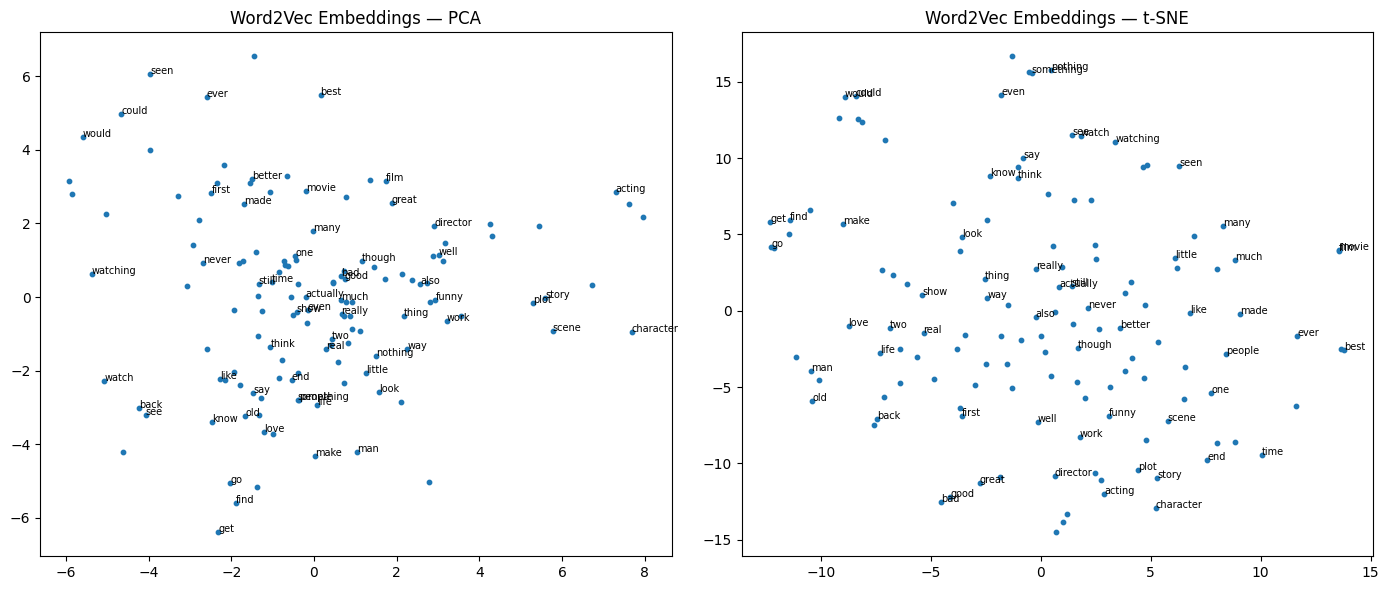

In [25]:
# Visualize embeddings with PCA and t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

top_words = [w for w, _ in Counter(all_tokens).most_common(150) if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in top_words])

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(vectors)
tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=15, init="pca").fit_transform(vectors)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in zip(axes, [pca_2d, tsne_2d], ["PCA", "t-SNE"]):
    ax.scatter(coords[:, 0], coords[:, 1], s=10)
    for i, word in enumerate(top_words[:60]):  # label a subset to keep it readable
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=7)
    ax.set_title(f"Word2Vec Embeddings — {title}")
plt.tight_layout()
plt.show()


## 9. Shared Evaluation Helper

Every model below is scored the same way so results are directly comparable:
accuracy, precision, recall, F1, ROC-AUC, and a confusion matrix, all logged
into a shared `results` dict. ROC curve points are kept separately in
`roc_data` (not saved to `metrics.json`, since raw curve arrays would bloat
that file) for the combined ROC comparison plot in Section 15.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)

results = {}
roc_data = {}  

def evaluate_model(name, y_true, y_pred, y_prob=None, train_time=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    cm = confusion_matrix(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    results[name] = {
        "accuracy": float(acc), "precision": float(prec), "recall": float(rec),
        "f1": float(f1), "roc_auc": float(auc) if auc is not None else None,
        "confusion_matrix": cm.tolist(), "train_time_sec": train_time,
    }

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_data[name] = (fpr, tpr)

    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

    plt.figure(figsize=(3.5, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/cm_{name.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()


## 10. Traditional Machine Learning Models

Before the neural/generative models, we establish strong **classical ML
baselines** on TF-IDF features: Logistic Regression, Multinomial Naive
Bayes, Linear SVM, Random Forest, and XGBoost. These are fast to train,
highly interpretable, and — on a bag-of-words task like sentiment analysis —
often surprisingly competitive with deep learning approaches. Each is tuned
with `GridSearchCV` over a small, targeted hyperparameter grid (cross-validated
on the training set) rather than trained with library defaults.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except (ModuleNotFoundError, ImportError):
    %pip install -q "xgboost==2.0.3"
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True



X_val_tfidf = tfidf_vectorizer.transform(X_text_val)

traditional_ml_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, random_state=SEED),
        "param_grid": {"C": [0.1, 1.0, 5.0, 10.0]},
    },
    "Naive Bayes": {
        "estimator": MultinomialNB(),
        "param_grid": {"alpha": [0.1, 0.5, 1.0, 2.0]},
    },
    "SVM (Linear)": {
        "estimator": LinearSVC(random_state=SEED, max_iter=5000),
        "param_grid": {"C": [0.1, 1.0, 5.0, 10.0]},
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=SEED, n_jobs=-1),
        "param_grid": {"n_estimators": [200, 400], "max_depth": [None, 30]},
    },
    "XGBoost": {
        "estimator": XGBClassifier(random_state=SEED, eval_metric="logloss", n_jobs=-1),
        "param_grid": {"n_estimators": [200, 400], "max_depth": [4, 6], "learning_rate": [0.05, 0.1]},
    },
}

traditional_ml_models = {}
traditional_ml_best_params = {}


Tuning Logistic Regression...
  Best params: {'C': 10.0} (val f1 via CV: 0.8600, 1.8s)

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87       392
    positive       0.87      0.88      0.87       391

    accuracy                           0.87       783
   macro avg       0.87      0.87      0.87       783
weighted avg       0.87      0.87      0.87       783



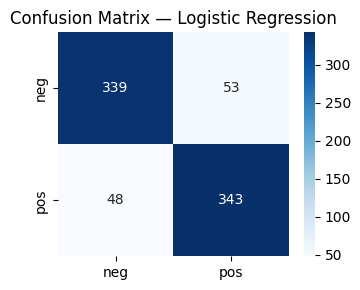

Tuning Naive Bayes...
  Best params: {'alpha': 0.5} (val f1 via CV: 0.8521, 1.1s)

=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.85      0.86      0.86       392
    positive       0.86      0.85      0.86       391

    accuracy                           0.86       783
   macro avg       0.86      0.86      0.86       783
weighted avg       0.86      0.86      0.86       783



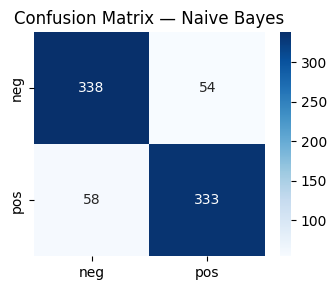

Tuning SVM (Linear)...
  Best params: {'C': 1.0} (val f1 via CV: 0.8537, 1.1s)

=== SVM (Linear) ===
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87       392
    positive       0.87      0.87      0.87       391

    accuracy                           0.87       783
   macro avg       0.87      0.87      0.87       783
weighted avg       0.87      0.87      0.87       783



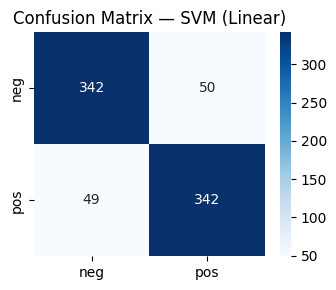

Tuning Random Forest...
  Best params: {'max_depth': 30, 'n_estimators': 400} (val f1 via CV: 0.8285, 8.2s)

=== Random Forest ===
              precision    recall  f1-score   support

    negative       0.87      0.82      0.84       392
    positive       0.83      0.87      0.85       391

    accuracy                           0.85       783
   macro avg       0.85      0.85      0.85       783
weighted avg       0.85      0.85      0.85       783



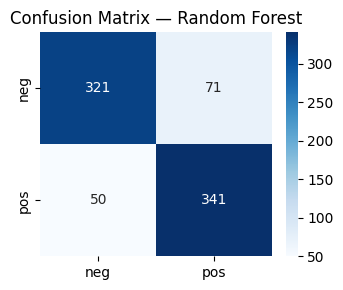

Tuning XGBoost...
  Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400} (val f1 via CV: 0.8223, 117.0s)

=== XGBoost ===
              precision    recall  f1-score   support

    negative       0.87      0.83      0.85       392
    positive       0.83      0.88      0.86       391

    accuracy                           0.85       783
   macro avg       0.85      0.85      0.85       783
weighted avg       0.85      0.85      0.85       783



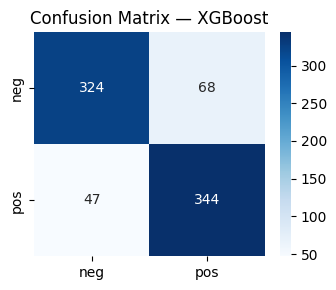

In [28]:
for name, cfg in traditional_ml_configs.items():
    print(f"Tuning {name}...")
    t0 = time.time()
    grid = GridSearchCV(cfg["estimator"], cfg["param_grid"], cv=3, scoring="f1", n_jobs=-1)
    grid.fit(X_train_tfidf, y_train)
    best_estimator = grid.best_estimator_
    tuning_time = time.time() - t0
    print(f"  Best params: {grid.best_params_} (val f1 via CV: {grid.best_score_:.4f}, {tuning_time:.1f}s)")
    traditional_ml_best_params[name] = grid.best_params_

    # LinearSVC has no predict_proba; wrap it so we can still get probabilities for ROC-AUC
    if name == "SVM (Linear)":
        best_estimator = CalibratedClassifierCV(best_estimator, cv=3)
        best_estimator.fit(X_train_tfidf, y_train)

    t0 = time.time()
    # (re-fit already done above for SVM; for the others, GridSearchCV's best_estimator_
    #  is already refit on the full training set by default)
    train_time = tuning_time if name != "SVM (Linear)" else tuning_time + (time.time() - t0)

    y_pred = best_estimator.predict(X_test_tfidf)
    y_prob = best_estimator.predict_proba(X_test_tfidf)[:, 1]
    evaluate_model(name, y_test, y_pred, y_prob, train_time)

    traditional_ml_models[name] = best_estimator
    with open(f"{MODELS_DIR}/{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}_model.pkl", "wb") as f:
        pickle.dump(best_estimator, f)


### Feature Importance (Logistic Regression coefficients)

For a linear model over TF-IDF features, the coefficients directly indicate
which words push the prediction toward positive or negative — no separate
explainability tool needed for a first look (a proper SHAP explanation is
added in Section 17 alongside the LIME demo).


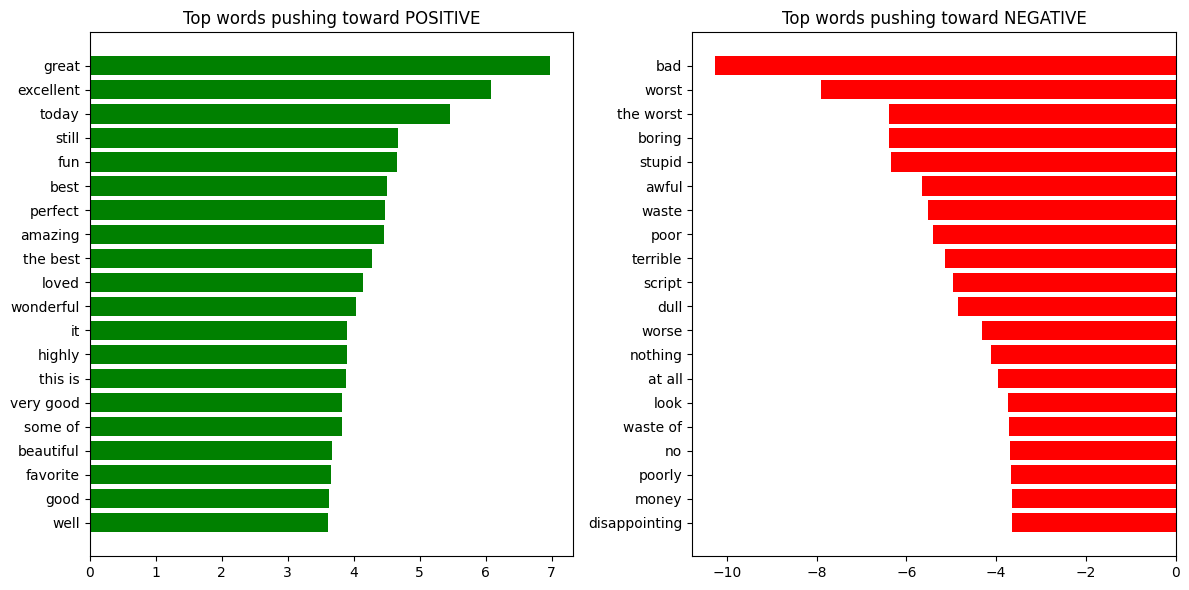

In [29]:
log_reg_model = traditional_ml_models["Logistic Regression"]
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs = log_reg_model.coef_[0]

top_positive_idx = np.argsort(coefs)[-20:][::-1]
top_negative_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(feature_names[top_positive_idx][::-1], coefs[top_positive_idx][::-1], color="green")
axes[0].set_title("Top words pushing toward POSITIVE")
axes[1].barh(feature_names[top_negative_idx][::-1], coefs[top_negative_idx][::-1], color="red")
axes[1].set_title("Top words pushing toward NEGATIVE")
plt.tight_layout()
plt.show()


## 11. Model — Hidden Markov Model (HMM)

Generative baseline: one HMM per class trained on word-id sequences; a new
review is classified by whichever HMM assigns it higher log-likelihood.

**Hyperparameter tuning:** the main HMM hyperparameter is the number of
hidden states per class. We grid-search a small range and pick the value
that maximizes validation accuracy before training the final model on the
full training set.


In [30]:
try:
    from hmmlearn import hmm as hmmlearn_hmm
except (ModuleNotFoundError, ImportError):
    %pip install -q "hmmlearn==0.3.2"
    from hmmlearn import hmm as hmmlearn_hmm

HMM_VOCAB = 3000

def seq_to_ids_clipped(texts):
    seqs = keras_tokenizer.texts_to_sequences(texts)
    return [np.clip(s, 0, HMM_VOCAB - 1) for s in seqs if len(s) > 0]

def to_hmm_format(seqs):
    lengths = [len(s) for s in seqs]
    X = np.concatenate(seqs).reshape(-1, 1)
    return X, lengths

def train_hmm_pair(n_states, train_texts_pos, train_texts_neg):
    pos_seqs = seq_to_ids_clipped(train_texts_pos)
    neg_seqs = seq_to_ids_clipped(train_texts_neg)
    X_pos, len_pos = to_hmm_format(pos_seqs)
    X_neg, len_neg = to_hmm_format(neg_seqs)

    hp = hmmlearn_hmm.CategoricalHMM(n_components=n_states, n_iter=20, random_state=SEED)
    hp.fit(X_pos, len_pos)
    hn = hmmlearn_hmm.CategoricalHMM(n_components=n_states, n_iter=20, random_state=SEED)
    hn.fit(X_neg, len_neg)
    return hp, hn

def hmm_pair_predict(hp, hn, texts):
    seqs = seq_to_ids_clipped(texts)
    preds = []
    for s in seqs:
        s2 = s.reshape(-1, 1)
        preds.append(1 if hp.score(s2) > hn.score(s2) else 0)
    return np.array(preds)


In [31]:
# Grid search over number of hidden states
HMM_STATE_CANDIDATES = [2, 3, 4, 5, 6]
hmm_tuning_results = []

train_texts_pos = X_text_train[y_train == 1]
train_texts_neg = X_text_train[y_train == 0]

for n_states in HMM_STATE_CANDIDATES:
    t0 = time.time()
    hp, hn = train_hmm_pair(n_states, train_texts_pos, train_texts_neg)
    val_preds = hmm_pair_predict(hp, hn, X_text_val)
    val_acc = accuracy_score(y_val, val_preds) if "accuracy_score" in dir() else (val_preds == y_val).mean()
    elapsed = time.time() - t0
    hmm_tuning_results.append({"n_states": n_states, "val_accuracy": val_acc, "time_sec": elapsed})
    print(f"n_states={n_states}: val_accuracy={val_acc:.4f} ({elapsed:.1f}s)")

hmm_tuning_df = pd.DataFrame(hmm_tuning_results).sort_values("val_accuracy", ascending=False)
best_n_states = int(hmm_tuning_df.iloc[0]["n_states"])
print(f"\nBest n_states: {best_n_states} (val_accuracy={hmm_tuning_df.iloc[0]['val_accuracy']:.4f})")
hmm_tuning_df


n_states=2: val_accuracy=0.8391 (13.6s)
n_states=3: val_accuracy=0.8327 (17.3s)
n_states=4: val_accuracy=0.8301 (22.4s)
n_states=5: val_accuracy=0.8365 (28.9s)
n_states=6: val_accuracy=0.8416 (27.9s)

Best n_states: 6 (val_accuracy=0.8416)


,n_states,val_accuracy,time_sec
4,6,0.841635,27.891734
0,2,0.839080,13.590715
3,5,0.836526,28.946588
1,3,0.832695,17.342875
2,4,0.830140,22.386429


In [32]:
# Retrain final HMM pair on the full training set using the best n_states found
from sklearn.metrics import accuracy_score

N_HMM_STATES = best_n_states

t0 = time.time()
hmm_pos, hmm_neg = train_hmm_pair(N_HMM_STATES, train_texts_pos, train_texts_neg)
hmm_train_time = time.time() - t0
print(f"Final HMM (n_states={N_HMM_STATES}) training took {hmm_train_time:.1f}s")


Final HMM (n_states=6) training took 23.0s



=== HMM ===
              precision    recall  f1-score   support

    negative       0.84      0.85      0.84       392
    positive       0.85      0.83      0.84       391

    accuracy                           0.84       783
   macro avg       0.84      0.84      0.84       783
weighted avg       0.84      0.84      0.84       783



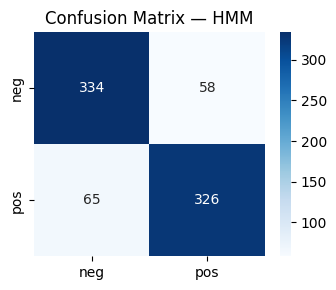

In [33]:
def hmm_predict_proba(texts):
    seqs = seq_to_ids_clipped(texts)
    preds, probs = [], []
    for s in seqs:
        s2 = s.reshape(-1, 1)
        score_pos = hmm_pos.score(s2)
        score_neg = hmm_neg.score(s2)
        m = max(score_pos, score_neg)
        p_pos = np.exp(score_pos - m) / (np.exp(score_pos - m) + np.exp(score_neg - m))
        preds.append(1 if p_pos > 0.5 else 0)
        probs.append(p_pos)
    return np.array(preds), np.array(probs)

y_pred_hmm, y_prob_hmm = hmm_predict_proba(X_text_test)
evaluate_model("HMM", y_test, y_pred_hmm, y_prob_hmm, hmm_train_time)

with open(f"{MODELS_DIR}/hmm_pos.pkl", "wb") as f:
    pickle.dump(hmm_pos, f)
with open(f"{MODELS_DIR}/hmm_neg.pkl", "wb") as f:
    pickle.dump(hmm_neg, f)


## 12. Models — RNN, LSTM, GRU, Bidirectional LSTM

Same architecture skeleton, only the recurrent layer differs — this isolates
the effect of cell type (and directionality) on performance.

**Hyperparameter tuning:** rather than fixing `embedding_dim`, `hidden_units`,
`dropout`, `learning_rate`, and `batch_size` by hand, we search over them
with Optuna. The search uses **LSTM** as the representative architecture
(all four models share the same skeleton, so the tuned hyperparameters
transfer across the family) trained for a few epochs per trial to keep the
search itself fast; the winning configuration is then used to train the
full RNN, LSTM, GRU, and BiLSTM models to convergence.


In [34]:
try:
    import optuna
except (ModuleNotFoundError, ImportError):
    %pip install -q "optuna==3.6.1"
    import optuna

from tensorflow.keras import layers, models, callbacks

optuna.logging.set_verbosity(optuna.logging.WARNING)


def build_recurrent_model(kind, embed_dim, hidden_units, dropout, learning_rate, bidirectional_variant=False):
    if kind == "RNN":
        rnn_layer = layers.SimpleRNN(hidden_units)
    elif kind == "LSTM":
        rnn_layer = layers.LSTM(hidden_units)
    elif kind == "GRU":
        rnn_layer = layers.GRU(hidden_units)
    elif kind == "BiLSTM":
        rnn_layer = layers.Bidirectional(layers.LSTM(hidden_units))
    else:
        raise ValueError(kind)

    model = models.Sequential([
        layers.Embedding(VOCAB_SIZE, embed_dim, input_length=MAX_LEN),
        rnn_layer,
        layers.Dropout(dropout),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


In [35]:
def optuna_objective(trial):
    embed_dim = trial.suggest_categorical("embed_dim", [64, 100, 128])
    hidden_units = trial.suggest_categorical("hidden_units", [32, 64, 96, 128])
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    tf.random.set_seed(SEED)
    model = build_recurrent_model("LSTM", embed_dim, hidden_units, dropout, learning_rate)
    es = callbacks.EarlyStopping(patience=1, restore_best_weights=True)

    history = model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                         epochs=4, batch_size=batch_size, callbacks=[es], verbose=0)
    val_acc = max(history.history["val_accuracy"])

    # Optuna minimizes by default; report negative accuracy so "best" == highest accuracy
    return -val_acc


N_TUNING_TRIALS = 15  # raise for a more thorough search if you have more time/compute

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(optuna_objective, n_trials=N_TUNING_TRIALS, show_progress_bar=True)

best_params = study.best_params
print("Best hyperparameters found:")
print(json.dumps(best_params, indent=2))
print(f"Best validation accuracy during search: {-study.best_value:.4f}")


  0%|          | 0/15 [00:00<?, ?it/s]

Best trial: 10. Best value: -0.804598: 100%|██████████| 15/15 [03:43<00:00, 14.89s/it]

Best hyperparameters found:
{
  "embed_dim": 128,
  "hidden_units": 32,
  "dropout": 0.3725382311125445,
  "learning_rate": 0.0003253425182484388,
  "batch_size": 32
}
Best validation accuracy during search: 0.8046


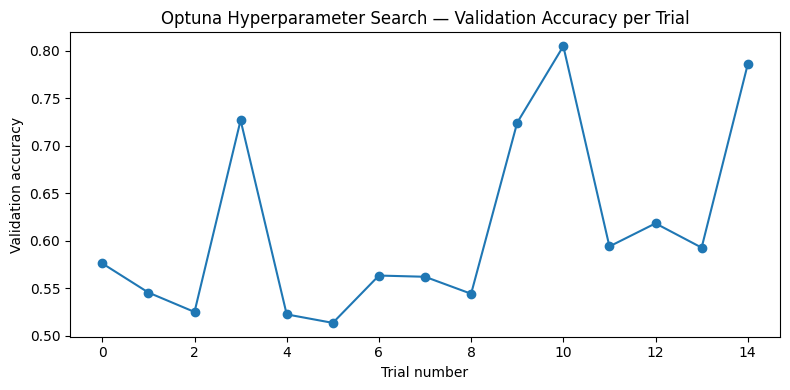

,number,val_accuracy,params_embed_dim,params_hidden_units,params_dropout,params_learning_rate,params_batch_size
10,10,0.804598,128,32,0.372538,0.000325,32
14,14,0.785441,128,32,0.365607,0.000429,32
3,3,0.726692,128,96,0.472796,0.000241,32
9,9,0.724138,128,64,0.461438,0.001539,64
12,12,0.618135,128,32,0.314169,0.000333,32
11,11,0.593870,128,32,0.387225,0.000312,32
13,13,0.592593,128,128,0.498506,0.000248,32
0,0,0.575990,100,32,0.459853,0.000773,128
6,6,0.563218,100,64,0.234761,0.001883,32
7,7,0.561941,128,64,0.413973,0.001330,64


In [36]:
# Visualize the tuning results
trials_df = study.trials_dataframe()
trials_df["val_accuracy"] = -trials_df["value"]
trials_df = trials_df.sort_values("val_accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(trials_df)), trials_df["val_accuracy"].sort_index(), marker="o")
ax.set_xlabel("Trial number")
ax.set_ylabel("Validation accuracy")
ax.set_title("Optuna Hyperparameter Search — Validation Accuracy per Trial")
plt.tight_layout()
plt.show()

trials_df[["number", "val_accuracy", "params_embed_dim", "params_hidden_units",
           "params_dropout", "params_learning_rate", "params_batch_size"]].head(10)


Final config -> embed_dim=128, hidden_units=32, dropout=0.373, lr=0.00033, batch_size=32, epochs=12
Epoch 1/12
115/115 [==============================] - 3s 22ms/step - loss: 0.6967 - accuracy: 0.5074 - val_loss: 0.6919 - val_accuracy: 0.5211 - lr: 3.2534e-04
Epoch 2/12
115/115 [==============================] - 2s 20ms/step - loss: 0.6762 - accuracy: 0.5925 - val_loss: 0.6951 - val_accuracy: 0.5134 - lr: 3.2534e-04
Epoch 3/12
115/115 [==============================] - 2s 20ms/step - loss: 0.6341 - accuracy: 0.6962 - val_loss: 0.7008 - val_accuracy: 0.5147 - lr: 1.6267e-04
Epoch 4/12
115/115 [==============================] - 2s 20ms/step - loss: 0.5593 - accuracy: 0.8005 - val_loss: 0.7084 - val_accuracy: 0.5057 - lr: 8.1336e-05

=== RNN ===
              precision    recall  f1-score   support

    negative       0.53      0.45      0.49       392
    positive       0.52      0.61      0.56       391

    accuracy                           0.53       783
   macro avg       0.53      

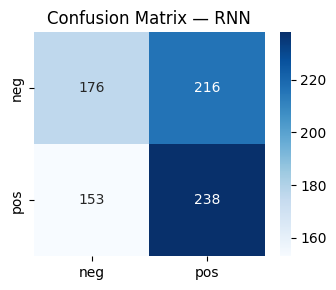

In [37]:
# Final training config: tuned hyperparameters applied to all 4 architectures,
# now trained for the full epoch budget (not the shortened tuning budget).
EMBED_DIM = best_params["embed_dim"]
HIDDEN_UNITS = best_params["hidden_units"]
DROPOUT = best_params["dropout"]
LEARNING_RATE = best_params["learning_rate"]
BATCH_SIZE = best_params["batch_size"]
EPOCHS = 12  # full budget for final training; early stopping will cut this short if needed

print(f"Final config -> embed_dim={EMBED_DIM}, hidden_units={HIDDEN_UNITS}, "
      f"dropout={DROPOUT:.3f}, lr={LEARNING_RATE:.5f}, batch_size={BATCH_SIZE}, epochs={EPOCHS}")

recurrent_histories = {}  # name -> Keras History, used for the learning-curve plot below

def train_and_eval_recurrent(kind):
    tf.random.set_seed(SEED)
    model = build_recurrent_model(kind, EMBED_DIM, HIDDEN_UNITS, DROPOUT, LEARNING_RATE)
    es = callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    lr_sched = callbacks.ReduceLROnPlateau(patience=1, factor=0.5)

    t0 = time.time()
    history = model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es, lr_sched], verbose=1)
    train_time = time.time() - t0
    recurrent_histories[kind] = history.history

    y_prob = model.predict(X_test_pad, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    evaluate_model(kind, y_test, y_pred, y_prob, train_time)

    model.save(f"{MODELS_DIR}/{kind.lower()}_model.keras")
    return model

rnn_model = train_and_eval_recurrent("RNN")


Epoch 1/12
115/115 [==============================] - 4s 30ms/step - loss: 0.6933 - accuracy: 0.4962 - val_loss: 0.6930 - val_accuracy: 0.5185 - lr: 3.2534e-04
Epoch 2/12
115/115 [==============================] - 3s 27ms/step - loss: 0.6911 - accuracy: 0.5334 - val_loss: 0.6912 - val_accuracy: 0.5057 - lr: 3.2534e-04
Epoch 3/12
115/115 [==============================] - 3s 27ms/step - loss: 0.6808 - accuracy: 0.5914 - val_loss: 0.6819 - val_accuracy: 0.5402 - lr: 3.2534e-04
Epoch 4/12
115/115 [==============================] - 3s 27ms/step - loss: 0.5906 - accuracy: 0.7058 - val_loss: 0.5970 - val_accuracy: 0.6743 - lr: 3.2534e-04
Epoch 5/12
115/115 [==============================] - 3s 27ms/step - loss: 0.4478 - accuracy: 0.8295 - val_loss: 0.4595 - val_accuracy: 0.8174 - lr: 3.2534e-04
Epoch 6/12
115/115 [==============================] - 3s 27ms/step - loss: 0.3673 - accuracy: 0.8766 - val_loss: 0.4826 - val_accuracy: 0.7880 - lr: 3.2534e-04
Epoch 7/12
115/115 [====================

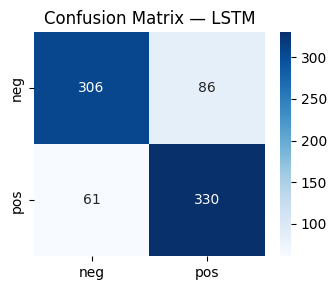

In [38]:
lstm_model = train_and_eval_recurrent("LSTM")


Epoch 1/12
115/115 [==============================] - 4s 29ms/step - loss: 0.6935 - accuracy: 0.5038 - val_loss: 0.6932 - val_accuracy: 0.5057 - lr: 3.2534e-04
Epoch 2/12
115/115 [==============================] - 3s 27ms/step - loss: 0.6915 - accuracy: 0.5525 - val_loss: 0.6929 - val_accuracy: 0.5045 - lr: 3.2534e-04
Epoch 3/12
115/115 [==============================] - 3s 26ms/step - loss: 0.6866 - accuracy: 0.5744 - val_loss: 0.6917 - val_accuracy: 0.5249 - lr: 3.2534e-04
Epoch 4/12
115/115 [==============================] - 3s 26ms/step - loss: 0.6709 - accuracy: 0.5980 - val_loss: 0.6907 - val_accuracy: 0.5313 - lr: 3.2534e-04
Epoch 5/12
115/115 [==============================] - 3s 27ms/step - loss: 0.6014 - accuracy: 0.6355 - val_loss: 0.6860 - val_accuracy: 0.5670 - lr: 3.2534e-04
Epoch 6/12
115/115 [==============================] - 3s 27ms/step - loss: 0.4566 - accuracy: 0.7515 - val_loss: 0.5318 - val_accuracy: 0.7484 - lr: 3.2534e-04
Epoch 7/12
115/115 [====================

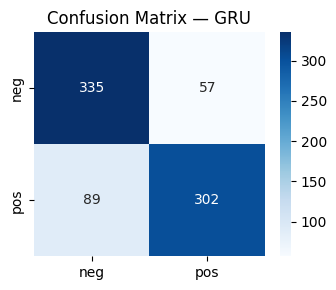

In [39]:
gru_model = train_and_eval_recurrent("GRU")


Epoch 1/12
115/115 [==============================] - 6s 34ms/step - loss: 0.6922 - accuracy: 0.5208 - val_loss: 0.6891 - val_accuracy: 0.5888 - lr: 3.2534e-04
Epoch 2/12
115/115 [==============================] - 4s 30ms/step - loss: 0.5888 - accuracy: 0.7189 - val_loss: 0.4208 - val_accuracy: 0.8276 - lr: 3.2534e-04
Epoch 3/12
115/115 [==============================] - 4s 31ms/step - loss: 0.2725 - accuracy: 0.8963 - val_loss: 0.4065 - val_accuracy: 0.8238 - lr: 3.2534e-04
Epoch 4/12
115/115 [==============================] - 4s 31ms/step - loss: 0.1231 - accuracy: 0.9622 - val_loss: 0.4124 - val_accuracy: 0.8519 - lr: 3.2534e-04
Epoch 5/12
115/115 [==============================] - 4s 31ms/step - loss: 0.0525 - accuracy: 0.9874 - val_loss: 0.5761 - val_accuracy: 0.8404 - lr: 1.6267e-04
Epoch 6/12
115/115 [==============================] - 4s 31ms/step - loss: 0.0327 - accuracy: 0.9932 - val_loss: 0.5709 - val_accuracy: 0.8416 - lr: 8.1336e-05

=== BiLSTM ===
              precision 

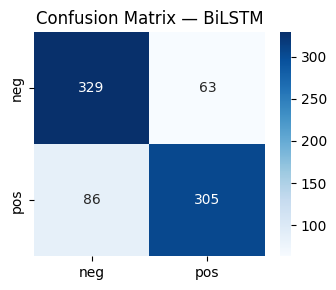

In [40]:
bilstm_model = train_and_eval_recurrent("BiLSTM")


### Learning Curves (Training vs. Validation)

Training and validation accuracy/loss per epoch for each recurrent model —
useful for spotting overfitting (validation curve diverging upward/away from
the training curve) versus underfitting (both curves plateauing at a low
value).


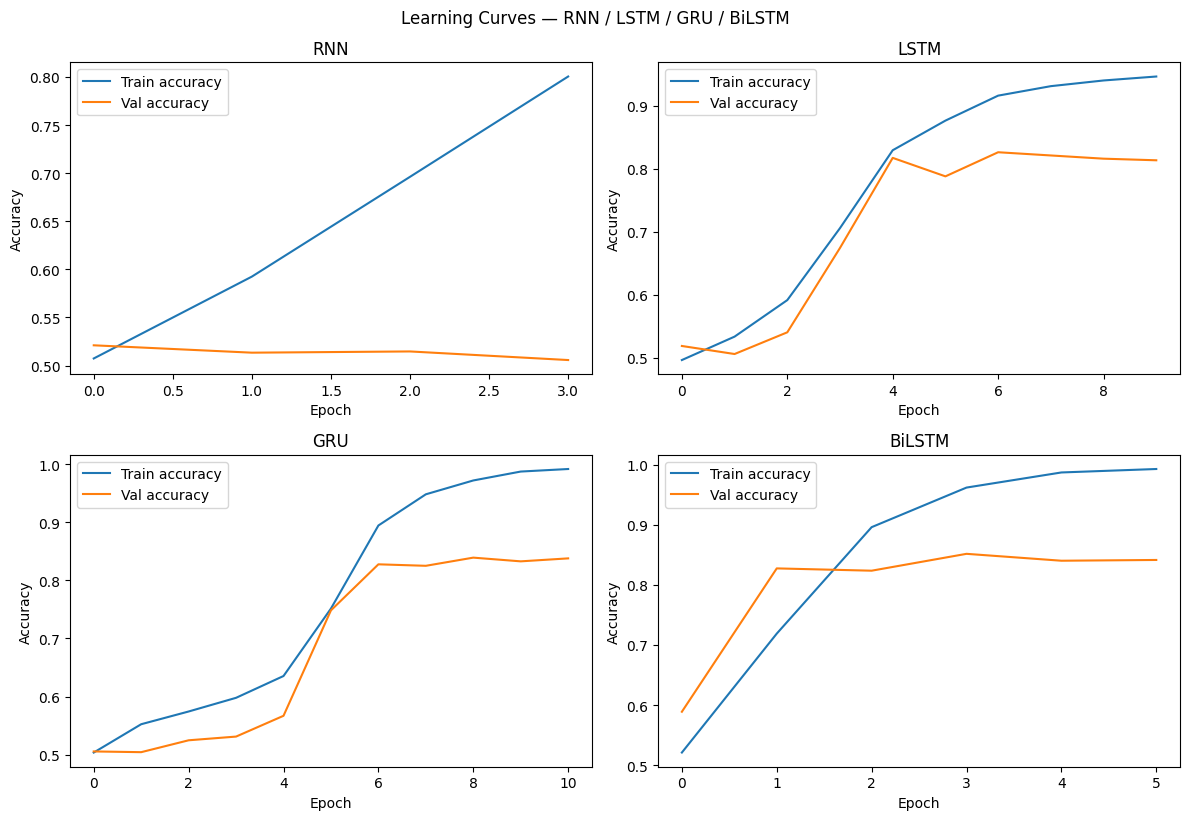

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (kind, hist) in zip(axes.ravel(), recurrent_histories.items()):
    ax.plot(hist["accuracy"], label="Train accuracy")
    ax.plot(hist["val_accuracy"], label="Val accuracy")
    ax.set_title(kind)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
plt.tight_layout()
plt.suptitle("Learning Curves — RNN / LSTM / GRU / BiLSTM", y=1.02)
plt.show()


## 13. Model — Fine-tuned Transformer (DistilBERT)

Fine-tunes `distilbert-base-uncased` on raw (uncleaned) text — transformers
handle subword tokenization and casing internally, so we deliberately skip
the classical cleaning pipeline here for a fairer "transformer as intended" comparison.

**Hyperparameter tuning:** we compare a small grid of learning rates with a
single quick epoch each, pick the one with the best validation accuracy,
then fine-tune the final model from scratch with that learning rate for the
full epoch budget.


In [42]:
try:
    from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification, create_optimizer
except (ModuleNotFoundError, ImportError):
    %pip install -q "transformers==4.40.0" "accelerate==0.30.0" "sentencepiece==0.2.0"
    from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification, create_optimizer

TRANSFORMER_MAX_LEN = 256
MODEL_NAME = "distilbert-base-uncased"

# Use the ORIGINAL (uncleaned) text for the transformer
X_raw_train, X_raw_temp, _, _ = train_test_split(
    df["review"].values, df["sentiment"].values, test_size=0.30, random_state=SEED, stratify=df["sentiment"].values)
X_raw_val, X_raw_test, _, _ = train_test_split(
    X_raw_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, padding=True,
                      max_length=TRANSFORMER_MAX_LEN, return_tensors="tf")

train_enc, val_enc, test_enc = tokenize(X_raw_train), tokenize(X_raw_val), tokenize(X_raw_test)

TF_BATCH = 16
train_ds = tf.data.Dataset.from_tensor_slices((dict(train_enc), y_train)).shuffle(1000).batch(TF_BATCH)
val_ds   = tf.data.Dataset.from_tensor_slices((dict(val_enc), y_val)).batch(TF_BATCH)
test_ds  = tf.data.Dataset.from_tensor_slices((dict(test_enc), y_test)).batch(TF_BATCH)


In [43]:
# Small learning-rate grid search (1 quick epoch per candidate)
LR_CANDIDATES = [2e-5, 3e-5, 5e-5]
transformer_tuning_results = []
steps_per_epoch = len(y_train) // TF_BATCH

for lr in LR_CANDIDATES:
    tf.random.set_seed(SEED)
    trial_model = TFDistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    trial_optimizer, _ = create_optimizer(
        init_lr=lr, num_warmup_steps=int(0.06 * steps_per_epoch),
        num_train_steps=steps_per_epoch, weight_decay_rate=0.01)
    trial_model.compile(optimizer=trial_optimizer,
                         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                         metrics=["accuracy"])
    history = trial_model.fit(train_ds, validation_data=val_ds, epochs=1, verbose=0)
    val_acc = history.history["val_accuracy"][-1]
    transformer_tuning_results.append({"learning_rate": lr, "val_accuracy": val_acc})
    print(f"learning_rate={lr:.0e}: val_accuracy={val_acc:.4f}")
    del trial_model  # free memory before the next candidate

transformer_tuning_df = pd.DataFrame(transformer_tuning_results).sort_values("val_accuracy", ascending=False)
best_lr = float(transformer_tuning_df.iloc[0]["learning_rate"])
print(f"\nBest learning rate: {best_lr:.0e} (val_accuracy={transformer_tuning_df.iloc[0]['val_accuracy']:.4f})")
transformer_tuning_df


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

learning_rate=2e-05: val_accuracy=0.8991


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

learning_rate=3e-05: val_accuracy=0.8966


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

learning_rate=5e-05: val_accuracy=0.9017

Best learning rate: 5e-05 (val_accuracy=0.9017)


,learning_rate,val_accuracy
2,0.00005,0.901660
0,0.00002,0.899106
1,0.00003,0.896552


In [44]:
transformer_model = TFDistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

TF_EPOCHS = 3  # full budget for the final run (tuning above only used 1 epoch per candidate)
optimizer, _ = create_optimizer(init_lr=best_lr, num_warmup_steps=int(0.06 * steps_per_epoch * TF_EPOCHS),
                                 num_train_steps=steps_per_epoch * TF_EPOCHS, weight_decay_rate=0.01)

transformer_model.compile(optimizer=optimizer,
                           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                           metrics=["accuracy"])

t0 = time.time()
transformer_history = transformer_model.fit(train_ds, validation_data=val_ds, epochs=TF_EPOCHS)
transformer_train_time = time.time() - t0


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
229/229 [==============================] - 531s 2s/step - loss: 0.4039 - accuracy: 0.8125 - val_loss: 0.3723 - val_accuracy: 0.8659
Epoch 2/3
229/229 [==============================] - 774s 3s/step - loss: 0.1617 - accuracy: 0.9401 - val_loss: 0.2276 - val_accuracy: 0.9170
Epoch 3/3
229/229 [==============================] - 788s 3s/step - loss: 0.0576 - accuracy: 0.9825 - val_loss: 0.2833 - val_accuracy: 0.9080


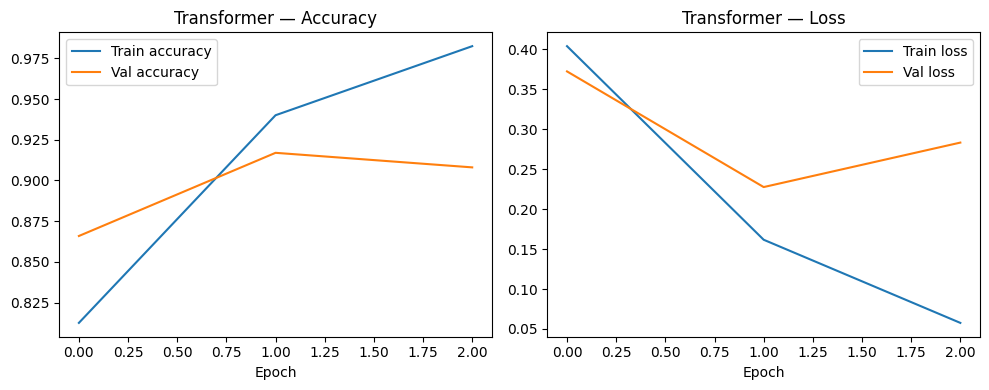

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(transformer_history.history["accuracy"], label="Train accuracy")
axes[0].plot(transformer_history.history["val_accuracy"], label="Val accuracy")
axes[0].set_title("Transformer — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(transformer_history.history["loss"], label="Train loss")
axes[1].plot(transformer_history.history["val_loss"], label="Val loss")
axes[1].set_title("Transformer — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


49/49 [==============================] - 47s 937ms/step

=== Transformer (DistilBERT) ===
              precision    recall  f1-score   support

    negative       0.93      0.91      0.92       392
    positive       0.91      0.93      0.92       391

    accuracy                           0.92       783
   macro avg       0.92      0.92      0.92       783
weighted avg       0.92      0.92      0.92       783



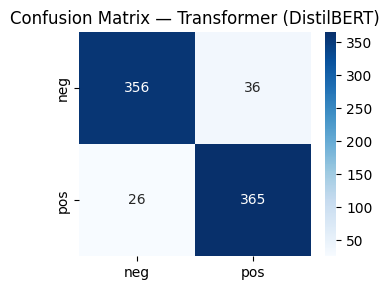

('c:\\Users\\Admin\\Desktop\\models/distilbert_sentiment\\tokenizer_config.json',
 'c:\\Users\\Admin\\Desktop\\models/distilbert_sentiment\\special_tokens_map.json',
 'c:\\Users\\Admin\\Desktop\\models/distilbert_sentiment\\vocab.txt',
 'c:\\Users\\Admin\\Desktop\\models/distilbert_sentiment\\added_tokens.json',
 'c:\\Users\\Admin\\Desktop\\models/distilbert_sentiment\\tokenizer.json')

In [46]:
logits = transformer_model.predict(test_ds).logits
probs_transformer = tf.nn.softmax(logits, axis=1).numpy()
y_pred_transformer = np.argmax(probs_transformer, axis=1)
evaluate_model("Transformer (DistilBERT)", y_test, y_pred_transformer, probs_transformer[:, 1], transformer_train_time)

transformer_model.save_pretrained(f"{MODELS_DIR}/distilbert_sentiment")
tokenizer.save_pretrained(f"{MODELS_DIR}/distilbert_sentiment")


## 14. Attention Visualization (Transformer)

One way to peek inside the transformer: extract its self-attention weights
for a sample review and visualize which tokens the model attends to most
from the `[CLS]` token (the token used for the final classification
decision) in the last layer, averaged across attention heads.


Some layers from the model checkpoint at c:\Users\Admin\Desktop\models/distilbert_sentiment were not used when initializing TFDistilBertForSequenceClassification: ['dropout_98']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at c:\Users\Admin\Desktop\models/distilbert_sentiment and are newly initialized: ['dropout_118']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


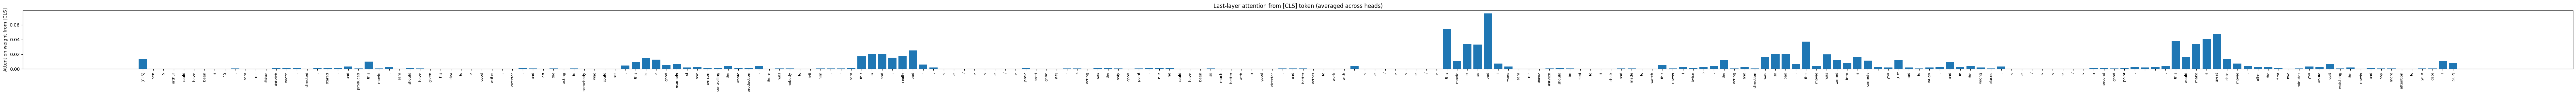

Review: Ben & Arthur COULD have been a 10. Sam Mraovich wrote, directed, stared, and produced this movie. Sam should have given his idea to a good writer, director, and left the acting to somebody who could a
True label: Negative


In [47]:
sample_review = X_raw_test[0]
inputs = tokenizer(sample_review, truncation=True, max_length=TRANSFORMER_MAX_LEN, return_tensors="tf")

attn_model = TFDistilBertForSequenceClassification.from_pretrained(
    f"{MODELS_DIR}/distilbert_sentiment", output_attentions=True)
outputs = attn_model(inputs, output_attentions=True)

# outputs.attentions: tuple of (num_layers) tensors, each (batch, num_heads, seq_len, seq_len)
last_layer_attn = outputs.attentions[-1][0]              # (num_heads, seq_len, seq_len)
avg_attn_from_cls = tf.reduce_mean(last_layer_attn, axis=0)[0].numpy()  # (seq_len,) attention FROM [CLS]

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].numpy())

fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.35), 3))
ax.bar(range(len(tokens)), avg_attn_from_cls)
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90, fontsize=8)
ax.set_ylabel("Attention weight from [CLS]")
ax.set_title("Last-layer attention from [CLS] token (averaged across heads)")
plt.tight_layout()
plt.show()

print("Review:", sample_review[:200])
print("True label:", "Positive" if y_test[0] == 1 else "Negative")


Ensemble cross‑validated F1: 0.9176 (+/- 0.0178)

=== Ensemble (Stacking) ===
              precision    recall  f1-score   support

    negative       0.94      0.91      0.93       392
    positive       0.92      0.94      0.93       391

    accuracy                           0.93       783
   macro avg       0.93      0.93      0.93       783
weighted avg       0.93      0.93      0.93       783



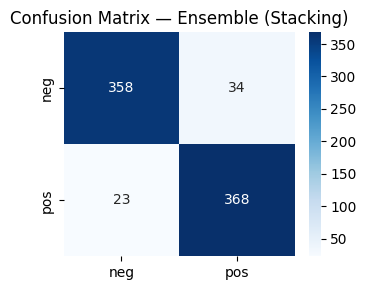

In [ ]:
#  Ensemble (Stacking) – combine all models using Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

#  Collect validation probabilities from every model

# Traditional ML models (already fitted)
val_probs = {}
for name in traditional_ml_models:
    if name == "SVM (Linear)":
        # CalibratedClassifierCV used during evaluation; already has predict_proba
        probs = traditional_ml_models[name].predict_proba(X_val_tfidf)[:, 1]
    else:
        probs = traditional_ml_models[name].predict_proba(X_val_tfidf)[:, 1]
    val_probs[name] = probs

# HMM
_, probs_hmm = hmm_predict_proba(X_text_val)   # returns (preds, probs)
val_probs["HMM"] = probs_hmm

# Recurrent models (RNN, LSTM, GRU, BiLSTM)
recurrent_models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bilstm_model
}
for name, model in recurrent_models.items():
    probs = model.predict(X_val_pad, verbose=0).ravel()
    val_probs[name] = probs


# Here we use the in-memory variables.
val_enc = tokenizer(
    X_text_val.tolist(),
    truncation=True,
    padding=True,
    max_length=TRANSFORMER_MAX_LEN,
    return_tensors="tf"
)
logits_val = transformer_model(val_enc).logits
probs_trans_val = tf.nn.softmax(logits_val, axis=1).numpy()[:, 1]
val_probs["Transformer (DistilBERT)"] = probs_trans_val

# Create feature matrix (n_val_samples x n_models)
model_names = list(val_probs.keys())
X_val_ensemble = np.column_stack([val_probs[name] for name in model_names])

#  Train meta‑learner (Logistic Regression) with cross‑validation

meta_model = LogisticRegression(random_state=SEED, max_iter=1000)
cv_scores = cross_val_score(meta_model, X_val_ensemble, y_val, cv=5, scoring='f1')
print(f"Ensemble cross‑validated F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit on full validation set
meta_model.fit(X_val_ensemble, y_val)

# Save the meta‑model and the list of base model names
with open(f"{MODELS_DIR}/ensemble_meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)
with open(f"{MODELS_DIR}/ensemble_model_names.pkl", "wb") as f:
    pickle.dump(model_names, f)

#  Evaluate ensemble on the test set

# Collect test probabilities from each base model
test_probs = {}
for name in traditional_ml_models:
    if name == "SVM (Linear)":
        probs = traditional_ml_models[name].predict_proba(X_test_tfidf)[:, 1]
    else:
        probs = traditional_ml_models[name].predict_proba(X_test_tfidf)[:, 1]
    test_probs[name] = probs

_, probs_hmm_test = hmm_predict_proba(X_text_test)
test_probs["HMM"] = probs_hmm_test

for name, model in recurrent_models.items():
    probs = model.predict(X_test_pad, verbose=0).ravel()
    test_probs[name] = probs

test_enc = tokenizer(
    X_text_test.tolist(),
    truncation=True,
    padding=True,
    max_length=TRANSFORMER_MAX_LEN,
    return_tensors="tf"
)
logits_test = transformer_model(test_enc).logits
probs_trans_test = tf.nn.softmax(logits_test, axis=1).numpy()[:, 1]
test_probs["Transformer (DistilBERT)"] = probs_trans_test

X_test_ensemble = np.column_stack([test_probs[name] for name in model_names])
y_pred_ensemble = meta_model.predict(X_test_ensemble)
y_prob_ensemble = meta_model.predict_proba(X_test_ensemble)[:, 1]

# Evaluate and store results (reuse evaluate_model)
evaluate_model("Ensemble (Stacking)", y_test, y_pred_ensemble, y_prob_ensemble, train_time=None)

#  Save updated metrics.json (already done inside evaluate_model)
# The evaluate_model function already appends to the global `results` dict
# and saves metrics.json at the end of the notebook.
# to force‑save now:
with open(f"{MODELS_DIR}/metrics.json", "w") as f:
    json.dump(results, f, indent=2)

## 15. Model Comparison Dashboard

In [50]:
summary_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k != "confusion_matrix"}
    for name, r in results.items()
}).T.sort_values("f1", ascending=False)
summary_df.insert(0, "rank", range(1, len(summary_df) + 1))
summary_df


,rank,accuracy,precision,recall,f1,roc_auc,train_time_sec
Ensemble (Stacking),1,0.927203,0.915423,0.941176,0.928121,0.967430,NaN
Transformer (DistilBERT),2,0.920817,0.910224,0.933504,0.921717,0.968513,2093.208754
SVM (Linear),3,0.873563,0.872449,0.874680,0.873563,0.941659,1.075169
Logistic Regression,4,0.871009,0.866162,0.877238,0.871665,0.941333,1.826505
XGBoost,5,0.853129,0.834951,0.879795,0.856787,0.919972,116.974228
Naive Bayes,6,0.856960,0.860465,0.851662,0.856041,0.937934,1.089668
Random Forest,7,0.845466,0.827670,0.872123,0.849315,0.923704,8.166122
HMM,8,0.842912,0.848958,0.833760,0.841290,0.916531,22.987725
LSTM,9,0.812261,0.793269,0.843990,0.817844,0.860526,32.307908
GRU,10,0.813538,0.841226,0.772379,0.805333,0.877375,35.066623


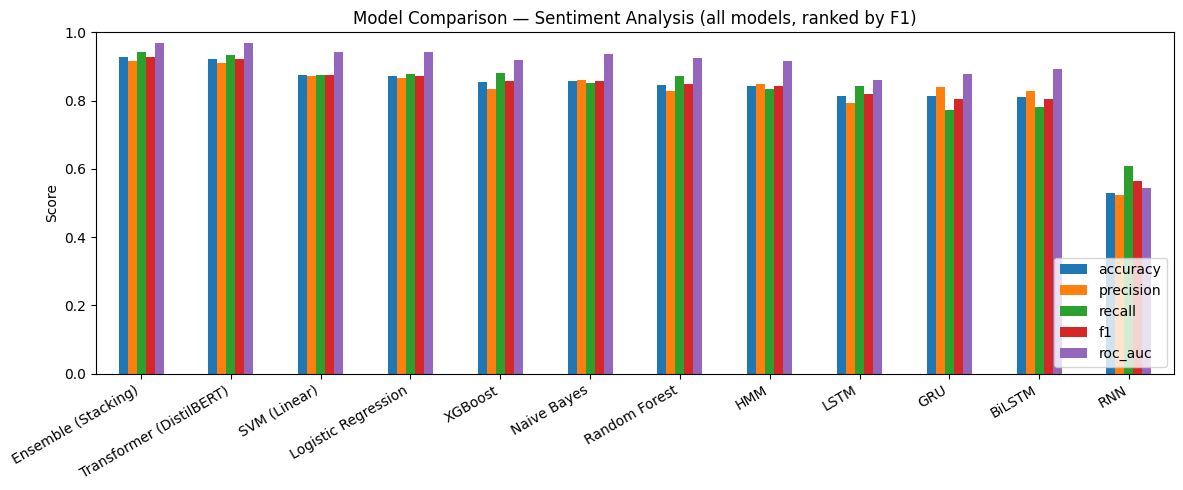

In [51]:
fig, ax = plt.subplots(figsize=(12, 5))
summary_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].astype(float).plot(kind="bar", ax=ax)
plt.title("Model Comparison — Sentiment Analysis (all models, ranked by F1)")
plt.ylabel("Score"); plt.ylim(0, 1); plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/comparison_chart.png", dpi=150)
plt.show()


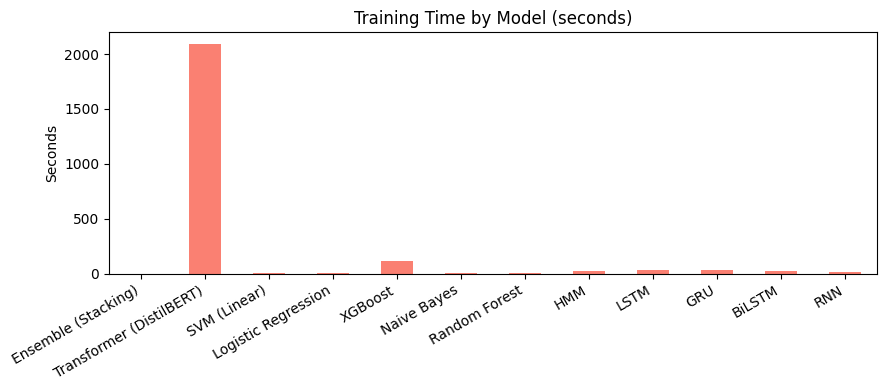

In [52]:
fig, ax = plt.subplots(figsize=(9, 4))
summary_df["train_time_sec"].astype(float).plot(kind="bar", ax=ax, color="salmon")
plt.title("Training Time by Model (seconds)")
plt.ylabel("Seconds"); plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.show()


### Combined ROC Curve

Every model with a probability output (all of them here) plotted on one ROC
curve, so the accuracy/AUC trade-offs are visible directly rather than only
as a table of numbers.


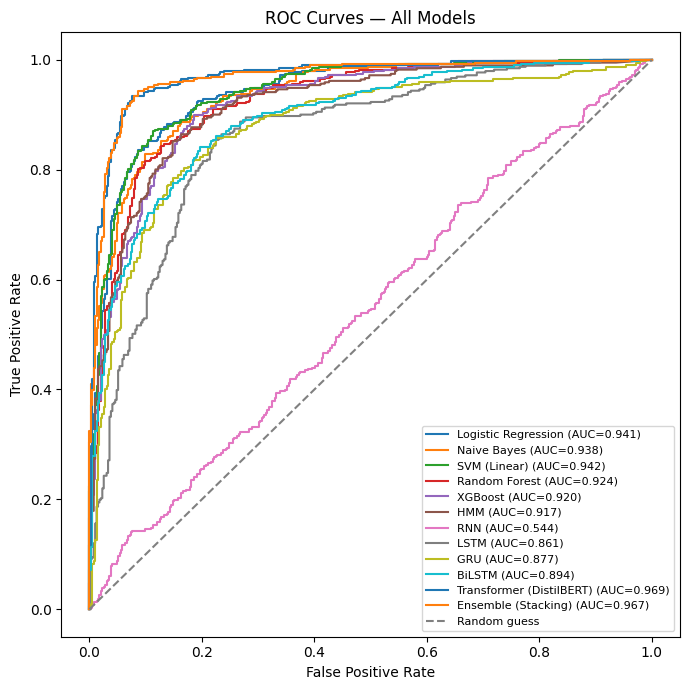

In [53]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, (fpr, tpr) in roc_data.items():
    auc = results[name]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/roc_curves_all_models.png", dpi=150)
plt.show()


## 16. Error Analysis

Inspect misclassified reviews from the best-performing model and look at the
confidence distribution for correct vs incorrect predictions.


In [57]:
best_model_name = summary_df.index[0]
print("Best model by F1:", best_model_name)

# Re-derive predictions/probs for the best model for inspection
recurrent_model_map = {"RNN": rnn_model, "LSTM": lstm_model, "GRU": gru_model, "BiLSTM": bilstm_model}

if best_model_name == "Transformer (DistilBERT)":
    inspect_texts, inspect_true, inspect_pred, inspect_prob = X_raw_test, y_test, y_pred_transformer, probs_transformer[:, 1]
elif best_model_name == "HMM":
    inspect_texts, inspect_true, inspect_pred, inspect_prob = X_text_test, y_test, y_pred_hmm, y_prob_hmm
elif best_model_name in recurrent_model_map:
    m = recurrent_model_map[best_model_name]
    probs = m.predict(X_test_pad, verbose=0).ravel()
    inspect_texts, inspect_true, inspect_pred, inspect_prob = X_text_test, y_test, (probs > 0.5).astype(int), probs
elif best_model_name in traditional_ml_models:
    m = traditional_ml_models[best_model_name]
    probs = m.predict_proba(X_test_tfidf)[:, 1]
    inspect_texts, inspect_true, inspect_pred, inspect_prob = X_text_test, y_test, (probs > 0.5).astype(int), probs
elif best_model_name == "Ensemble (Stacking)":
    # Use the ensemble predictions already computed
    inspect_texts, inspect_true, inspect_pred, inspect_prob = X_text_test, y_test, y_pred_ensemble, y_prob_ensemble
else:
    raise ValueError(f"Unrecognized best model name: {best_model_name}")

errors_df = pd.DataFrame({
    "text": inspect_texts,
    "true_label": inspect_true,
    "pred_label": inspect_pred,
    "confidence": inspect_prob,
})
misclassified = errors_df[errors_df.true_label != errors_df.pred_label]
print(f"Misclassified: {len(misclassified)} / {len(errors_df)} ({len(misclassified)/len(errors_df)*100:.1f}%)")
misclassified.sort_values("confidence", ascending=False).head(10)[["text", "true_label", "pred_label", "confidence"]]

Best model by F1: Ensemble (Stacking)
Misclassified: 57 / 783 (7.3%)


,text,true_label,pred_label,confidence
441,'ninteen eighty four' is a film about a futuri...,0,1,0.966844
658,there are those who gripe that this is not the...,0,1,0.962596
54,i understand there wa some conflict between le...,0,1,0.960314
10,solid comedy entertainment with musical interl...,0,1,0.956023
49,the one sheet and newspaper campaign suggested...,0,1,0.945516
496,during the civil war there were many case of d...,0,1,0.938130
157,woody allen who i have to confess at the outse...,0,1,0.924237
364,this is probably the first entry in the lance ...,0,1,0.917452
369,i think that movie can t be a scott s film tha...,0,1,0.910353
494,i have read all the comment on this film i am ...,0,1,0.906149


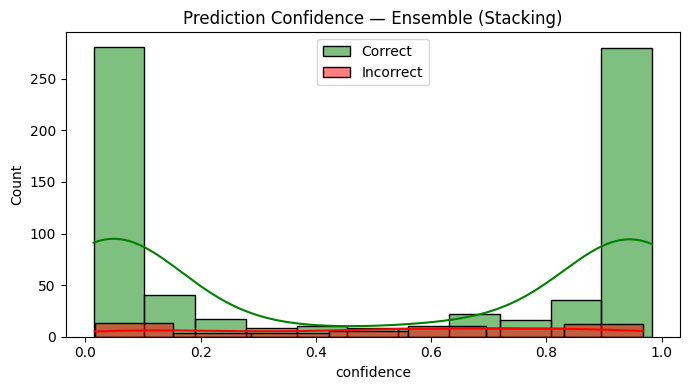

In [58]:
fig, ax = plt.subplots(figsize=(7, 4))
correct = errors_df[errors_df.true_label == errors_df.pred_label]["confidence"]
incorrect = errors_df[errors_df.true_label != errors_df.pred_label]["confidence"]
sns.histplot(correct, color="green", label="Correct", kde=True, ax=ax, alpha=0.5)
sns.histplot(incorrect, color="red", label="Incorrect", kde=True, ax=ax, alpha=0.5)
plt.title(f"Prediction Confidence — {best_model_name}")
plt.legend(); plt.tight_layout()
plt.show()

## 17. Interpretability Demo (LIME + SHAP)

A LIME explanation on one of the recurrent models, showing which words
pushed the prediction toward positive/negative, plus a SHAP explanation for
the Logistic Regression model (linear models have exact, fast SHAP values
via `LinearExplainer`, making them a natural complement to LIME's
model-agnostic but approximate explanations).


In [ ]:
from lime.lime_text import LimeTextExplainer
from IPython.display import HTML, display


 
# Choose which model to explain (LSTM by default)
# Options: rnn_model, lstm_model, gru_model, bilstm_model
# Or any traditional ML model with a predict_proba method (wrapper needed)

lime_target_model = lstm_model           # swap as desired





#  Define the prediction function for LIME


def predict_proba_for_lime(texts):
    cleaned = [cleaner.clean(t) for t in texts]
    padded = to_padded(cleaned)
    p1 = lime_target_model.predict(padded, verbose=0).ravel()
    return np.column_stack([1 - p1, p1])

#  Pick a sample review from the test set
#  If the best model is the transformer, use raw text from X_raw_test;
#  otherwise use the first review from the original dataframe.

if best_model_name == "Transformer (DistilBERT)" and 'X_raw_test' in globals():
    sample_text = X_raw_test[0]
else:
    sample_text = df.iloc[0]["review"]


# Create the LIME explainer and generate explanation

explainer = LimeTextExplainer(class_names=["negative", "positive"])
explanation = explainer.explain_instance(
    sample_text,
    predict_proba_for_lime,
    num_features=10          # number of most important words to show
)

# Display the explanation as HTML
display(HTML(f"""
<div style="width:1400px;background:white;padding:20px;">
{explanation.as_html()}
</div>
"""))

### SHAP Explanation (Logistic Regression)


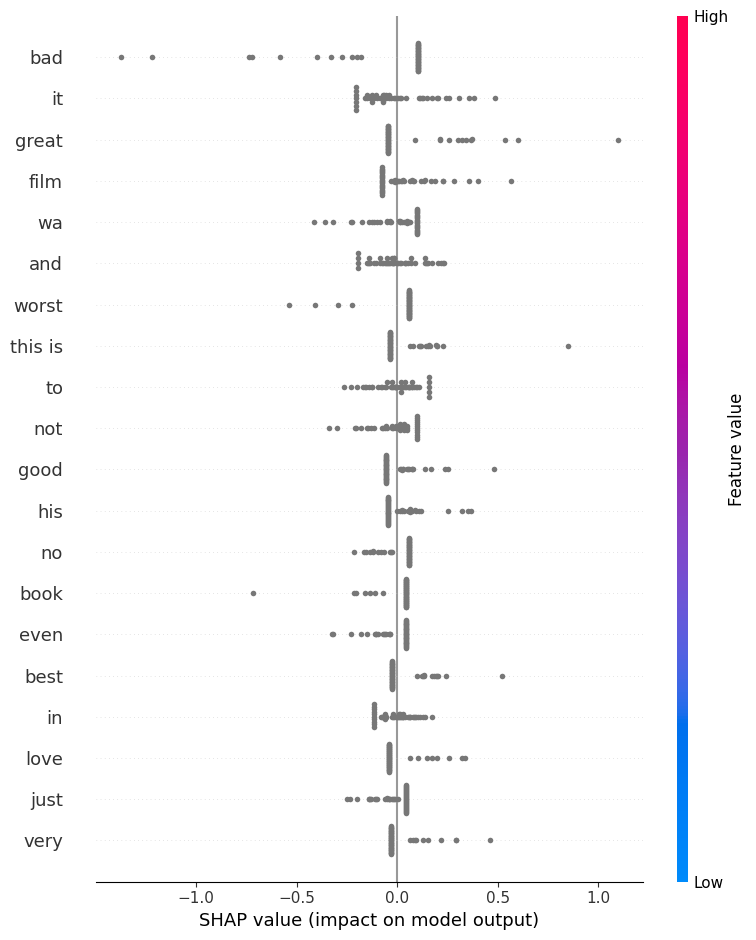

In [61]:
try:
    import shap
except (ModuleNotFoundError, ImportError):
    %pip install -q "shap==0.45.0"
    import shap

# LinearExplainer works directly and exactly (no sampling approximation) for linear models
shap_explainer = shap.LinearExplainer(log_reg_model, X_train_tfidf)
sample_tfidf = X_test_tfidf[:50]  # explain a small batch for speed
shap_values = shap_explainer(sample_tfidf)

shap.summary_plot(shap_values, sample_tfidf, feature_names=feature_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/shap_summary_logreg.png", dpi=150, bbox_inches="tight")
plt.show()


## 18. Save All Artifacts for the Streamlit App


In [62]:
with open(f"{MODELS_DIR}/keras_tokenizer.pkl", "wb") as f:
    pickle.dump(keras_tokenizer, f)

with open(f"{MODELS_DIR}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

w2v_model.save(f"{MODELS_DIR}/word2vec.model")

config = {"vocab_size": VOCAB_SIZE, "max_len": MAX_LEN, "hmm_vocab": HMM_VOCAB,
          "transformer_max_len": TRANSFORMER_MAX_LEN, "best_model": best_model_name,
          "tuned_hyperparameters": {
              "traditional_ml_family": traditional_ml_best_params,
              "hmm_n_states": N_HMM_STATES,
              "recurrent_family": best_params,
              "transformer_learning_rate": best_lr,
              "transformer_epochs": TF_EPOCHS,
          }}
with open(f"{MODELS_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

with open(f"{MODELS_DIR}/metrics.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved artifacts:", sorted(os.listdir(MODELS_DIR)))


Saved artifacts: ['bilstm_model.keras', 'cm_bilstm.png', 'cm_ensemble_(stacking).png', 'cm_gru.png', 'cm_hmm.png', 'cm_logistic_regression.png', 'cm_lstm.png', 'cm_naive_bayes.png', 'cm_random_forest.png', 'cm_rnn.png', 'cm_svm_(linear).png', 'cm_transformer_(distilbert).png', 'cm_xgboost.png', 'comparison_chart.png', 'config.json', 'distilbert_sentiment', 'ensemble_meta_model.pkl', 'ensemble_model_names.pkl', 'gru_model.keras', 'hmm_neg.pkl', 'hmm_pos.pkl', 'keras_tokenizer.pkl', 'logistic_regression_model.pkl', 'lstm_model.keras', 'metrics.json', 'naive_bayes_model.pkl', 'random_forest_model.pkl', 'rnn_model.keras', 'roc_curves_all_models.png', 'shap_summary_logreg.png', 'svm_linear_model.pkl', 'tfidf_vectorizer.pkl', 'word2vec.model', 'xgboost_model.pkl']


In [63]:
import os
print(os.path.abspath(MODELS_DIR))

c:\Users\Admin\Desktop\models
